# Complete Single-Stage Run: Midpoint Geometry

In [61]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, '../../..')
sys.path.insert(0, '../..')
sys.path.insert(0, '.')

plt.style.use('../../../configurations/style.mplstyle')
datafiles           = Path('../../../datafiles')
baseline_filenames  = "../Output_files/baseline_flat_midpoint_alpha"
possible_alpha      = ["A0.5", "A1.0", "A3.0", "A5.0"]
baseline_paths      = {a : Path(f"{baseline_filenames}_{a}/emcee.h5") for a in possible_alpha}
for value in baseline_paths.values(): assert value.is_file(), f"File {value} does not exist."

from src.top_hat.geometric_eff import geometric_efficiency_flat_midpoint, geometric_efficiency_fixed, create_geometric_efficiency_lognormal_interpolator

print('Imports complete.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports complete.


In [62]:
import emcee
fixed_params = {}
for alpha in possible_alpha:
    #test_backend    = baseline_paths["A5.0"]
    test_backend        = baseline_paths.get(alpha)
    samples             = emcee.backends.HDFBackend(test_backend).get_chain(flat=True, discard=3000, thin = 10)
    mu_e                = samples[:, 2]
    sigma_e             = samples[:, 3]
    e_vals, s_vals      = np.percentile(mu_e, [50, 5, 95]), np.percentile(sigma_e, [50, 5, 95])
    med_e, e_05, e_95   = e_vals
    med_s, s_05, s_95   = s_vals
    #print(f"Alpha: {alpha} | L_mu_E: {med_e:.3f} [{e_05:.3f}, {e_95:.3f}] | sigma_E: {med_s:.3f} [{s_05:.3f}, {s_95:.3f}]")
    A_index = samples[:, 0]
    log_values = emcee.backends.HDFBackend(test_backend).get_log_prob(flat=True, discard=3000, thin = 10)
    #maximum_log_value = np.max(log_values)
    #only take values with A < 3
    maximum_log_value = np.max(log_values[A_index < 3])
    max_indices = np.where(log_values == maximum_log_value)[0]
    max_e = mu_e[max_indices][0]
    
    max_s = sigma_e[max_indices][0]
    max_A = A_index[max_indices][0]
    print(f"Maximum log-probability: {maximum_log_value:.2f} at A={max_A:.2f}, L_mu_E={max_e:.2f}, sigma_E={max_s:.2f}")
    fixed_params[alpha] = {"L_mu_E": max_e, "sigma_E": max_s, "A_index": max_A}

Maximum log-probability: -4.18 at A=3.00, L_mu_E=3.35, sigma_E=0.37
Maximum log-probability: -3.92 at A=2.74, L_mu_E=3.32, sigma_E=0.31
Maximum log-probability: -4.38 at A=2.77, L_mu_E=3.31, sigma_E=0.34
Maximum log-probability: -4.15 at A=2.96, L_mu_E=3.40, sigma_E=0.42


In [63]:
# Run configuration
from mcmc_runner_a import run_pop_a
geom_eff_func           = geometric_efficiency_flat_midpoint
nsbh_population_soft    = "fiducial_delayed_cut_sfho" # sfho
nsbh_population_hard    = "fiducial_delayed_cut_dd2" # dd2
nsbh_populations        = [nsbh_population_soft, nsbh_population_hard]
# Run the single complete MC chain for all alphas.
local_rate_dicts        = []
FJ_BNS                  = 1
for nsbh_pop in nsbh_populations:
    output, dict_rates = run_pop_a(
        alphas          =   possible_alpha,
        geom_eff_func   =   geom_eff_func,
        datafiles       =   datafiles,
        fixed_params    =   fixed_params,
        nsbh_population =   nsbh_pop,
        FJ_BNS          =   FJ_BNS,
    )
    local_rate_dicts.append(dict_rates)

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_sfho
Grid tensor computed for alpha A0.5.
Results archived at: Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_sfho/grid_eval.npz
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227


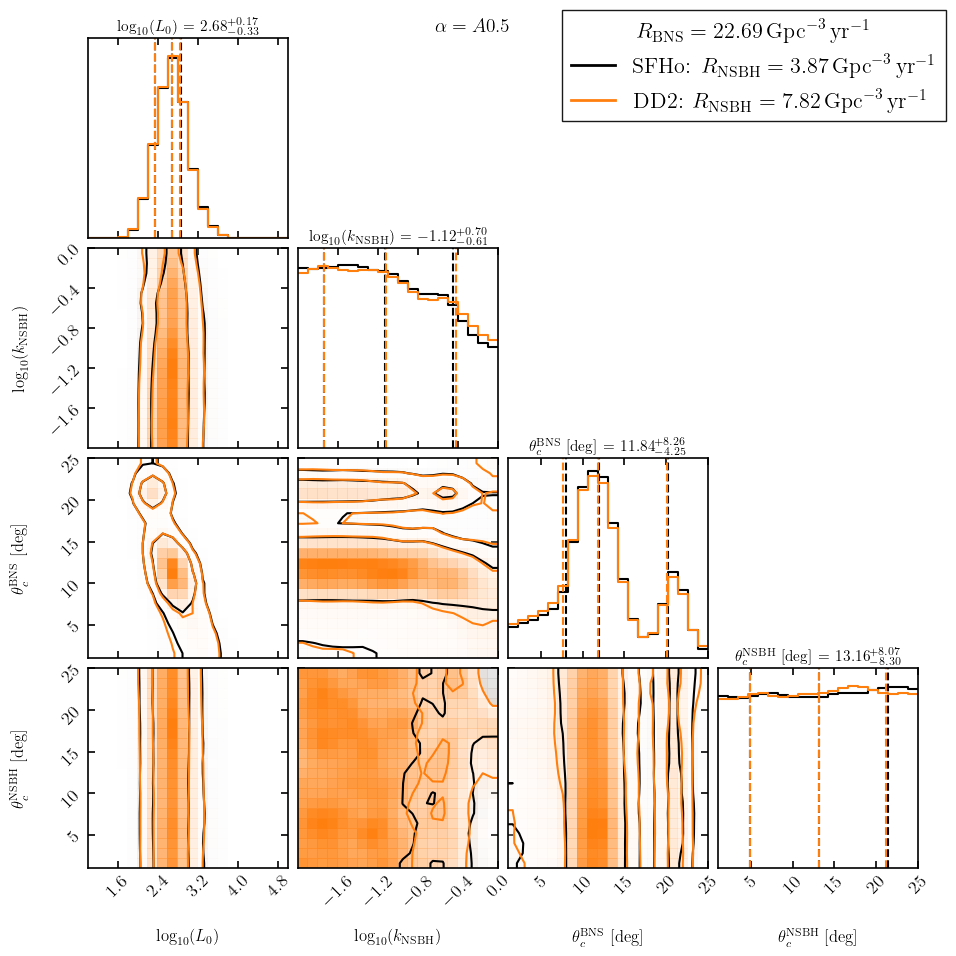

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -5.7793594512221675
Maximum log-likelihood value: -5.7734909403514125


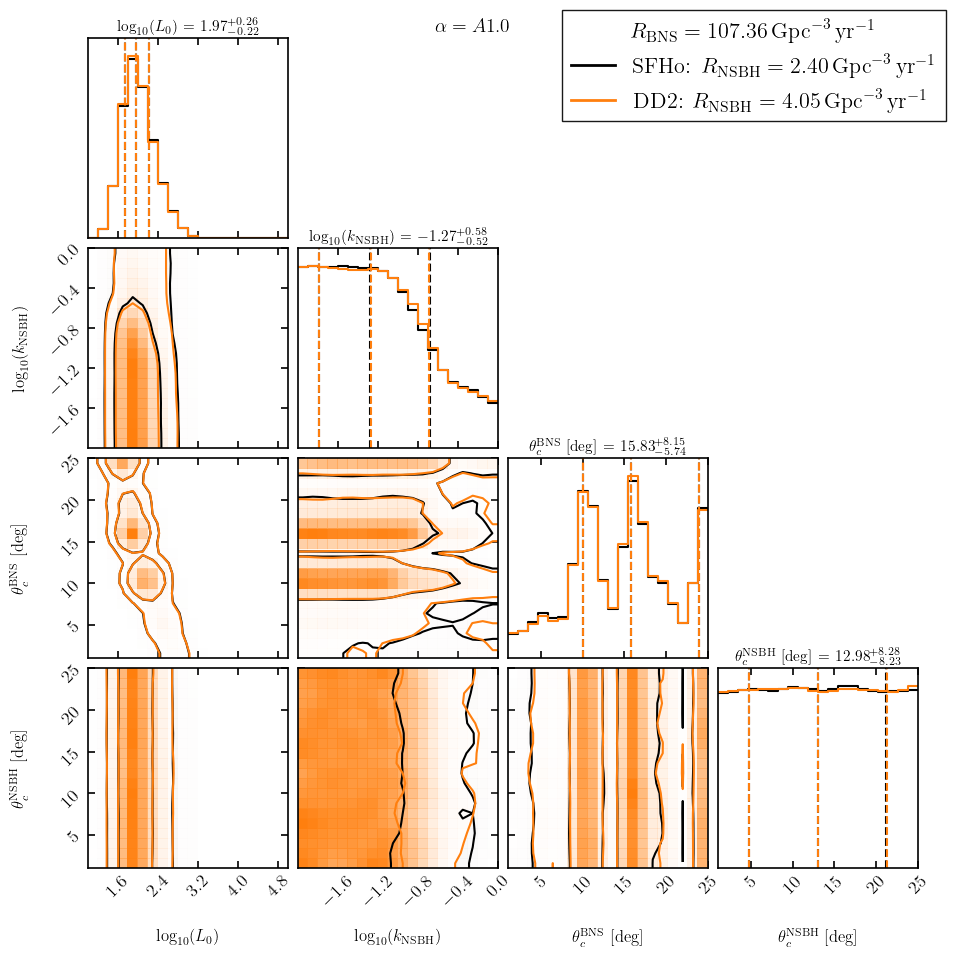

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -4.00483209337067
Maximum log-likelihood value: -4.004804707815868


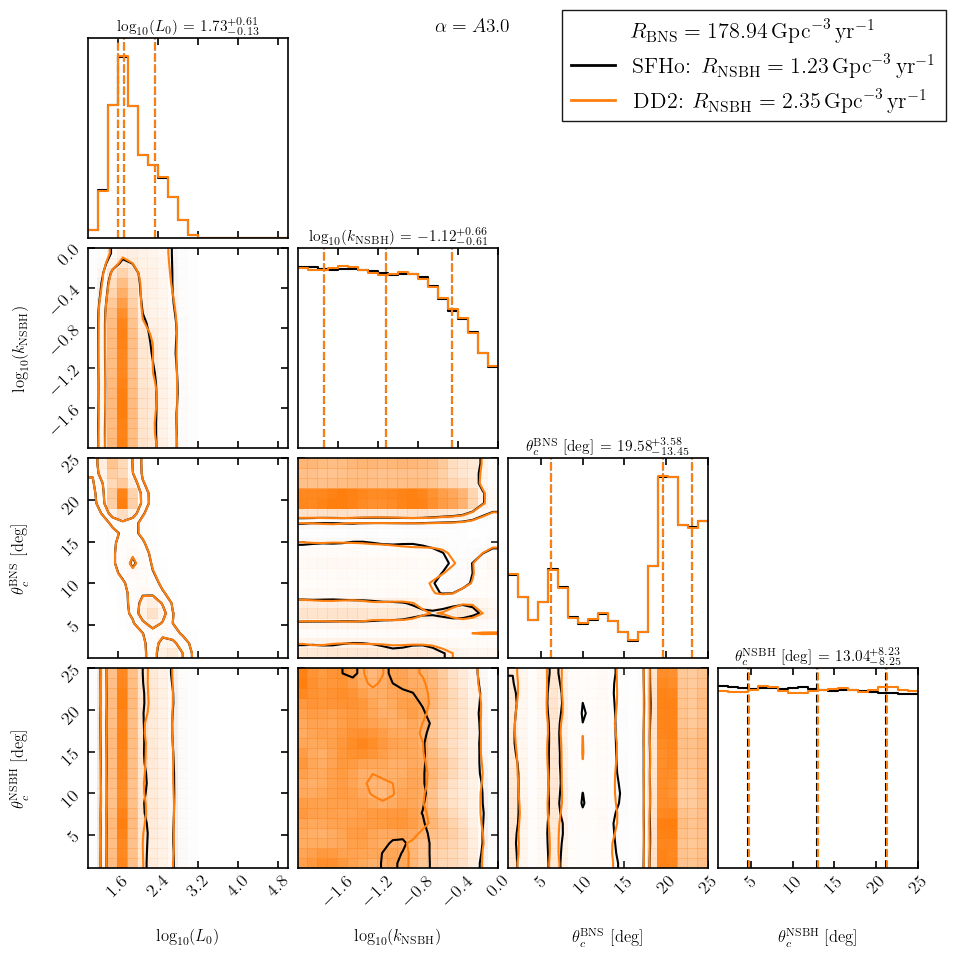

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -5.071116949787294
Maximum log-likelihood value: -5.071395189658885


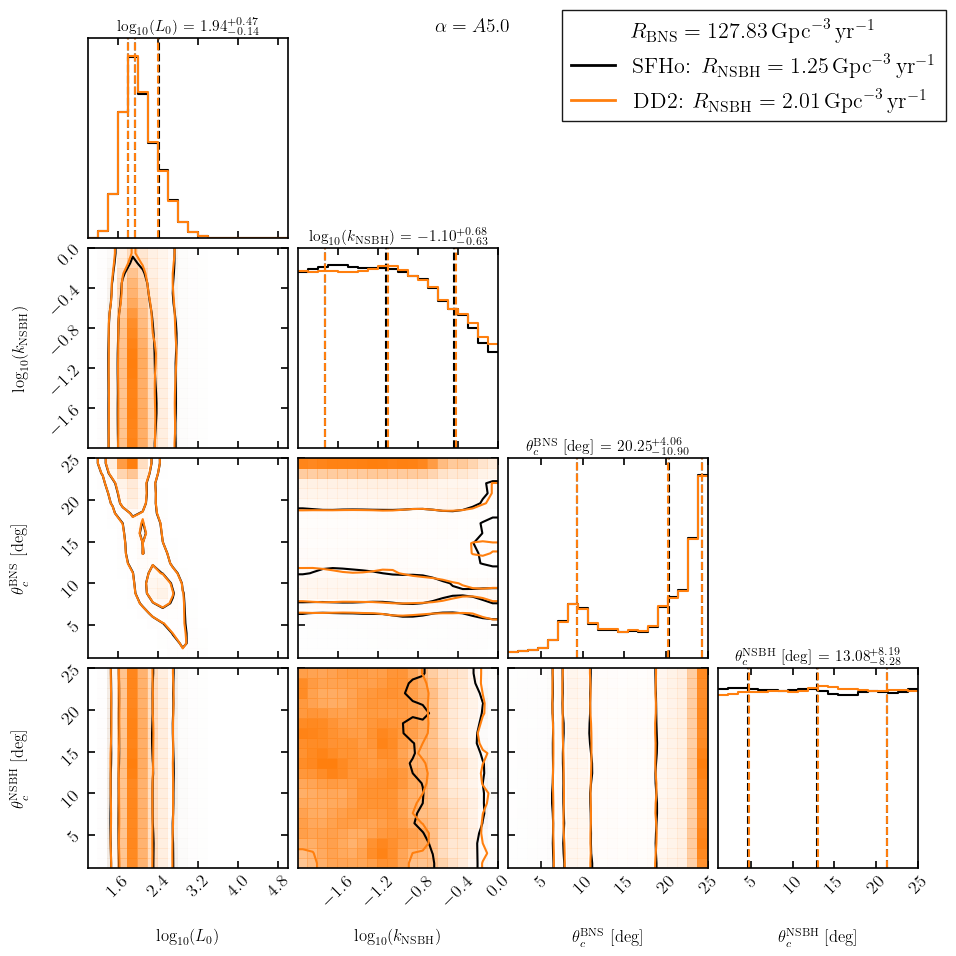

In [65]:
from mcmc_runner_a import plot_corner_grid_multiples
plot_corner_grid_multiples(alphas=possible_alpha, 
                           local_rate_dicts=local_rate_dicts, 
                           FJ_BNS=FJ_BNS,
                           nsbh_populations=nsbh_populations, 
                           geom_eff_func=geom_eff_func)

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -4.887333059311668
Maximum log-likelihood value: -4.887990802987227
Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248


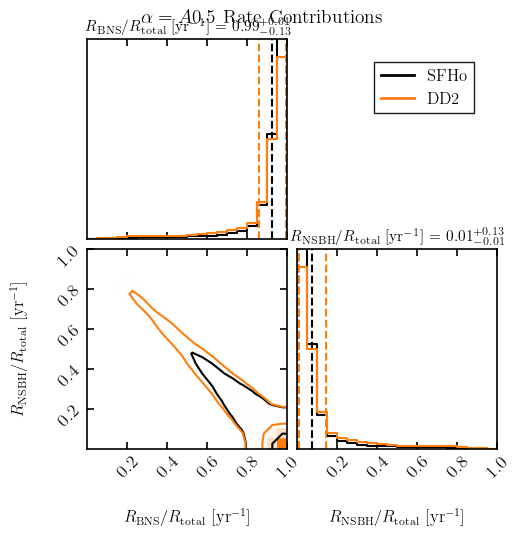

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -5.7793594512221675
Maximum log-likelihood value: -5.7734909403514125
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Computed total merger rate: 343741.1 yr^-1 (local R_0 = 107.4 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 11743.4 yr^-1 (local R_0 = 2.4 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A1.0
  BHNSs local rate R_0 = 2.4 Gpc^-3 yr^-1
  BHNSs total rate     = 11743 yr^-1
  1-year z sample size = 11743


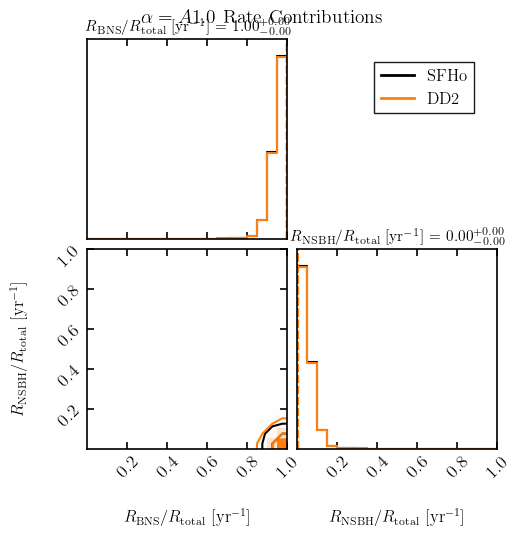

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -4.00483209337067
Maximum log-likelihood value: -4.004804707815868
Using redshift model: samples_fiducial_delayed_A3.0_BNSs_0.dat with 358417 BNSs.
Computed total merger rate: 360097.8 yr^-1 (local R_0 = 178.9 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 5191.6 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A3.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 5192 yr^-1
  1-year z sample size = 5191


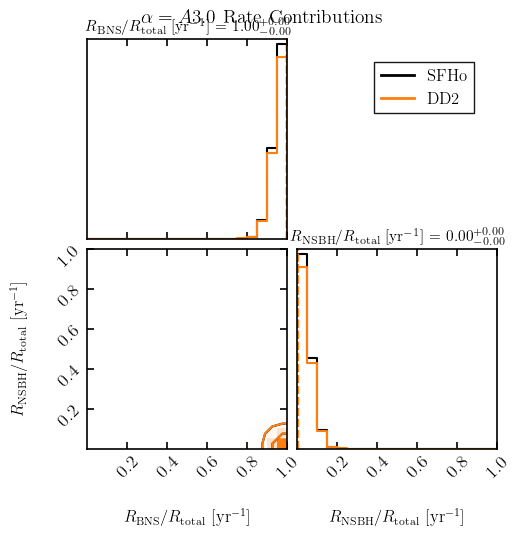

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_flat_midpoint_sfho
Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_1_geometric_efficiency_flat_midpoint_dd2
Maximum log-likelihood value: -5.071116949787294
Maximum log-likelihood value: -5.071395189658885
Using redshift model: samples_fiducial_delayed_A5.0_BNSs_0.dat with 136203 BNSs.
Computed total merger rate: 136874.3 yr^-1 (local R_0 = 127.8 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4322.7 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A5.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 4323 yr^-1
  1-year z sample size = 4322


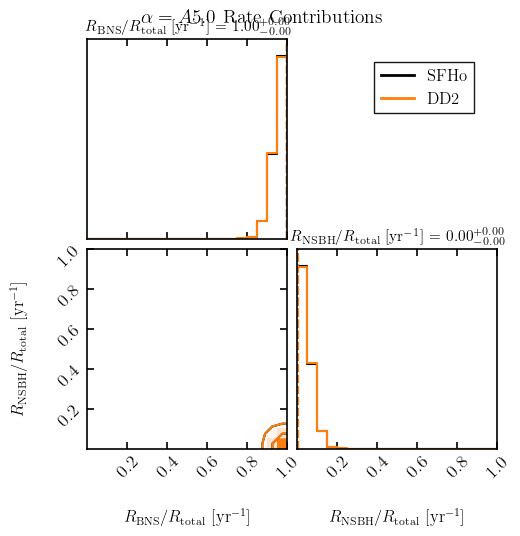

In [66]:
from mcmc_runner_a import posterior_rate_contribution_corner_plot
posterior_rate_contribution_corner_plot(alphas=possible_alpha, 
                                        local_rate_dicts=local_rate_dicts, 
                                        nsbh_populations=nsbh_populations, 
                                        FJ_BNS=FJ_BNS,
                                        geom_eff_func=geom_eff_func)

In [ ]:
1/0

ZeroDivisionError: division by zero

In [67]:
# Execution loop for different FJ_BNS values
fj_list = [0.3, 0.5, 1.0]
results_by_fj = {}

for fj in fj_list:
    local_rate_dicts = []
    for nsbh_pop in nsbh_populations:
        _, dict_rates = run_pop_a(
            alphas=possible_alpha,
            geom_eff_func=geom_eff_func,
            datafiles=datafiles,
            fixed_params=fixed_params,
            nsbh_population=nsbh_pop,
            FJ_BNS=fj,
        )
        local_rate_dicts.append(dict_rates)
    results_by_fj[fj] = local_rate_dicts

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 19248.6 yr^-1 (local R_0 = 3.9 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut_sfho / A0.5
  BHNSs local rate R_0 = 3.9 Gpc^-3 yr^-1
  BHNSs total rate     = 19249 yr^-1
  1-year z sample size = 19248
Creating new directory : Output_files/grid_likelihood_alpha_A0.5_0.3_geometric_efficiency_flat_midpoint_sfho
Grid tensor computed for alpha A0.5.
Results archived at: Output_files/grid_likelihood_alpha_A0.5_0.3_geometric_efficiency_flat_midpoint_sfho/grid_eval.npz
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 

In [68]:
import corner
import matplotlib.pyplot as plt
import numpy as np

def plot_joint_posteriors(
    results_by_fj, fj_list, alpha_list, nsbh_populations
):
    """Generates a grid of 2D rate contribution posteriors."""
    rows = len(alpha_list)
    cols = len(fj_list)
    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(4 * cols, 4 * rows),
        squeeze=False,
    )

    for r_idx, alpha in enumerate(alpha_list):
        for c_idx, fj in enumerate(fj_list):
            ax = axes[r_idx, c_idx]
            rates = results_by_fj[fj]

            # Extract samples for the designated alpha
            soft_samples = rates[0][alpha]
            hard_samples = rates[1][alpha]
            samples = np.column_stack((soft_samples, hard_samples))

            # Render 2D density plot
            corner.hist2d(
                samples[:, 0],
                samples[:, 1],
                ax=ax,
                plot_datapoints=False,
                plot_density=True,
                no_fill_contours=False,
            )

            # Apply labels
            if r_idx == rows - 1:
                ax.set_xlabel(f"Rate ({nsbh_populations[0]})")
            if c_idx == 0:
                ax.set_ylabel(f"Rate ({nsbh_populations[1]})")

            ax.set_title(f"Alpha: {alpha} | FJ: {fj}")

    fig.tight_layout()
    return fig, axes

In [ ]:
1/0

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5_dd2
Maximum log-likelihood value: -6.071132490235129


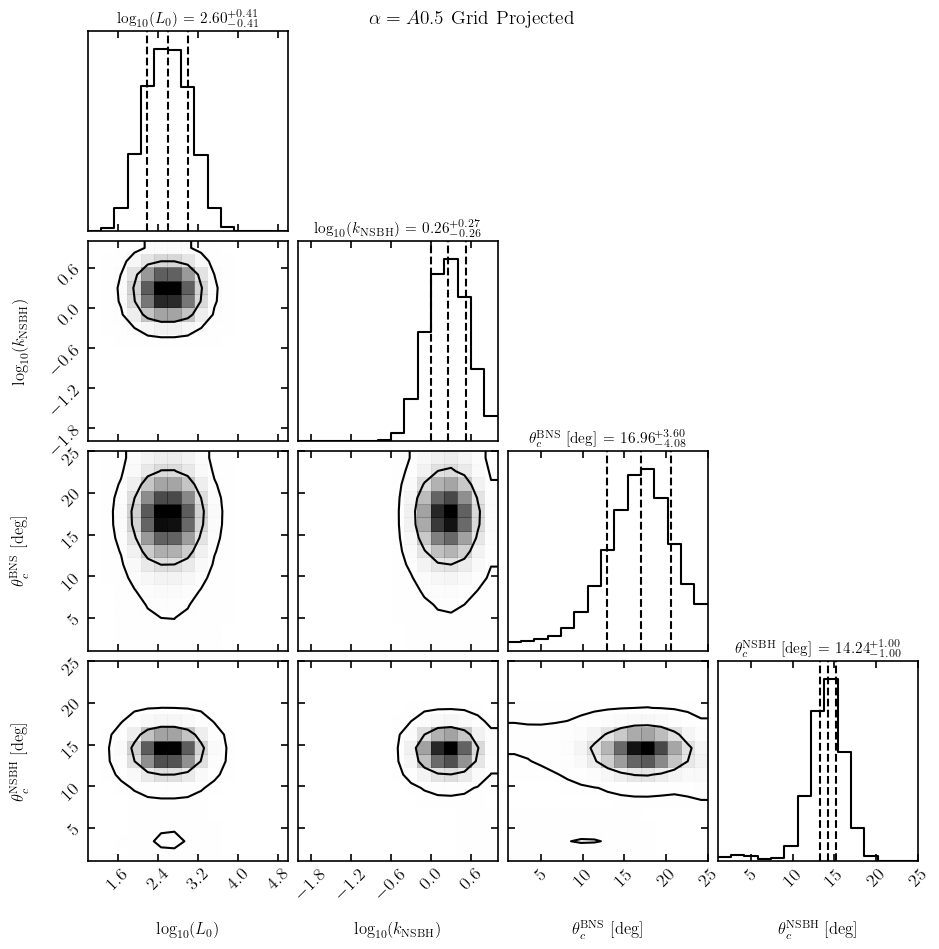

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0_dd2
Maximum log-likelihood value: -6.13772699414891


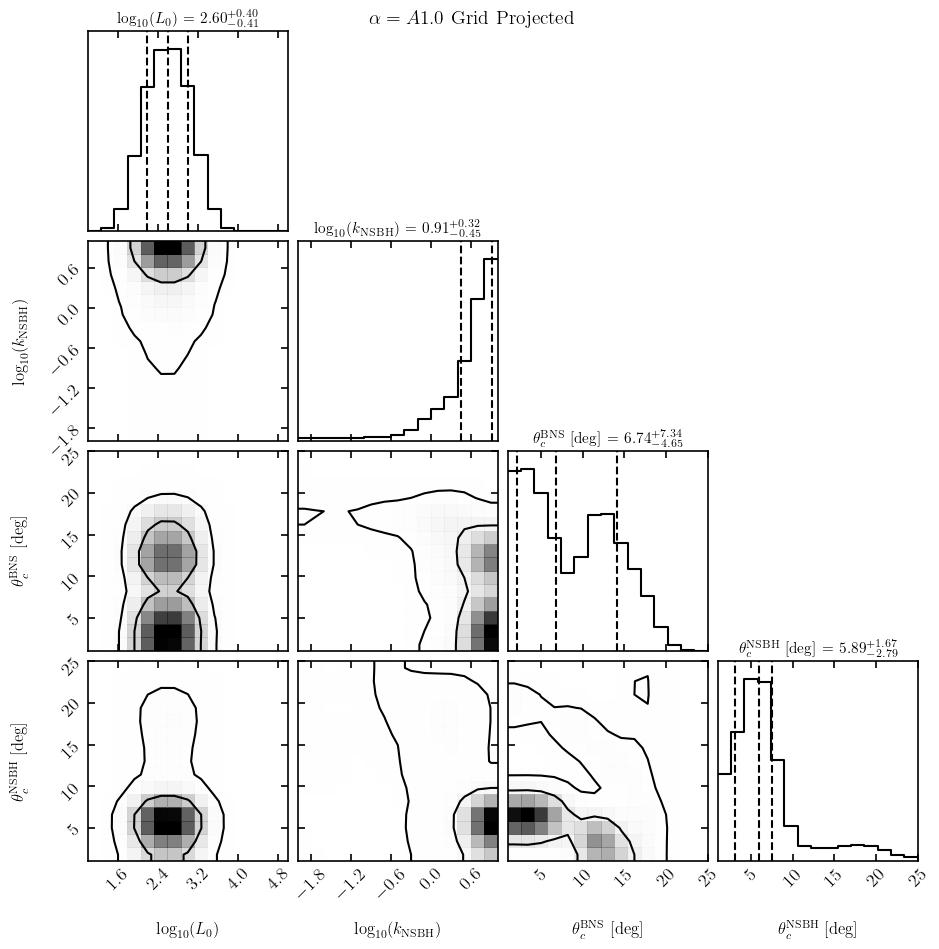

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0_dd2
Maximum log-likelihood value: -5.243405884259628


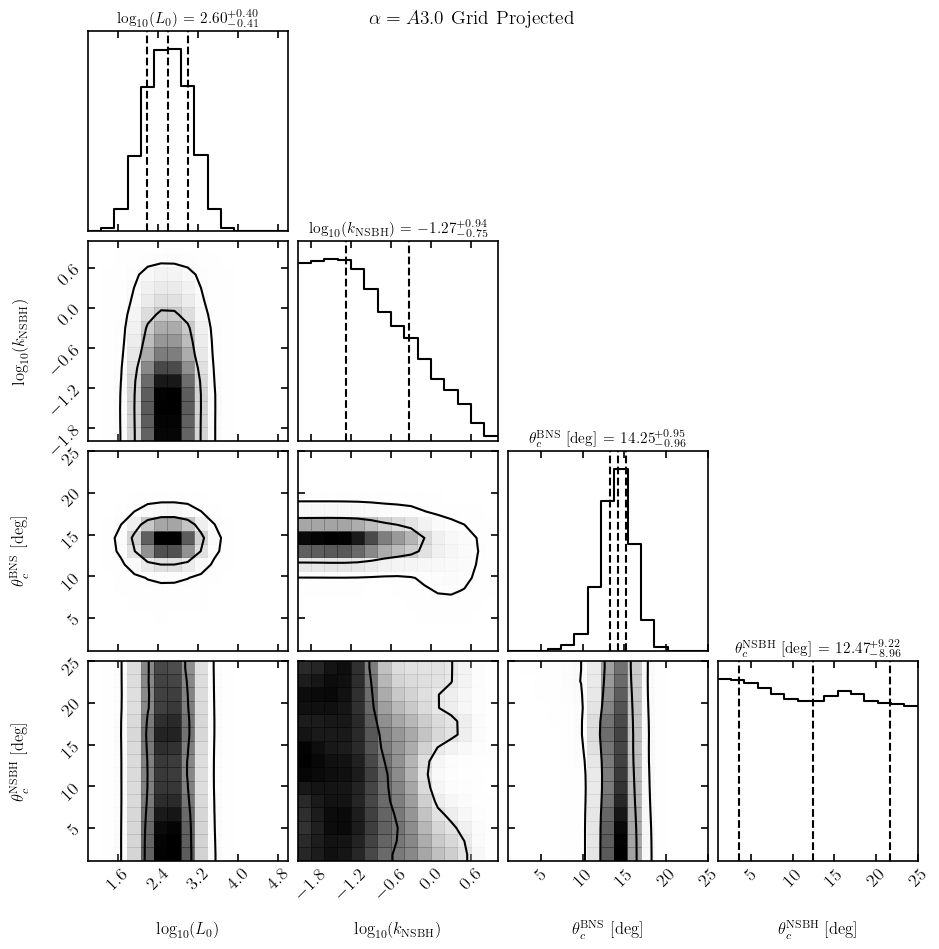

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0_dd2
Maximum log-likelihood value: -7.722326617159057


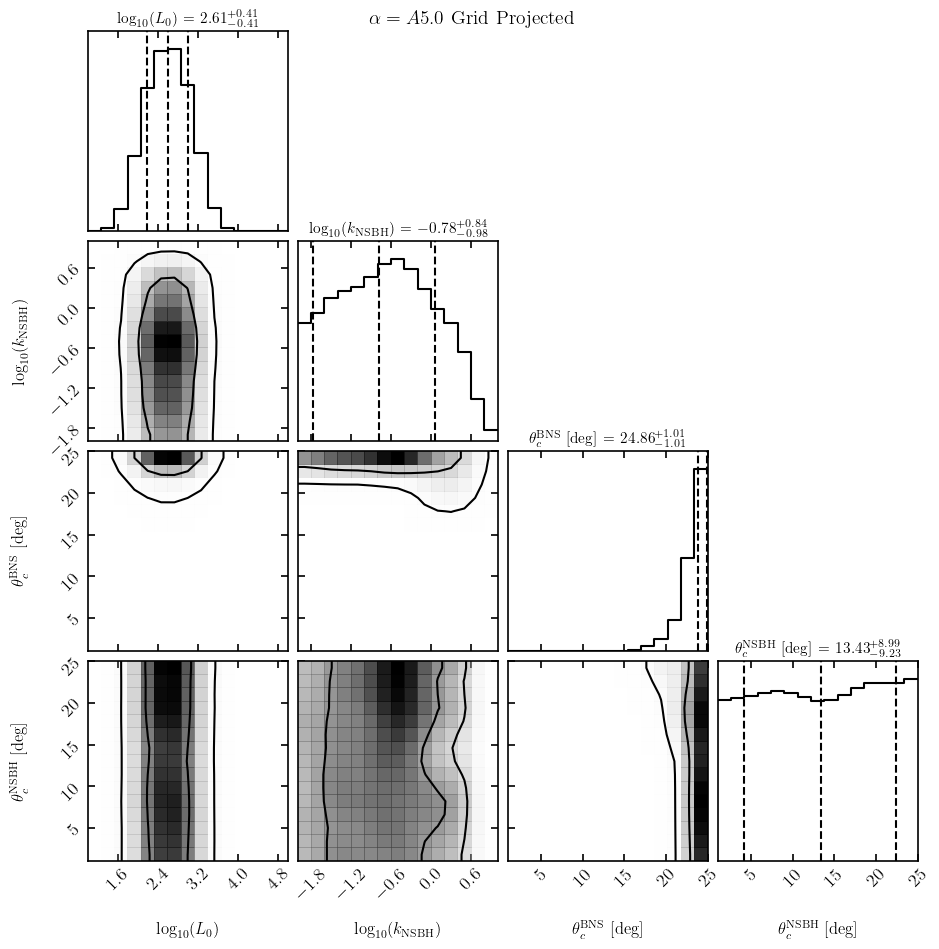

In [ ]:
from mcmc_runner_a import plot_corner_grid

plot_corner_grid(alphas=possible_alpha, nsbh_population = nsbh_population)

In [ ]:
1/0

ZeroDivisionError: division by zero

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332


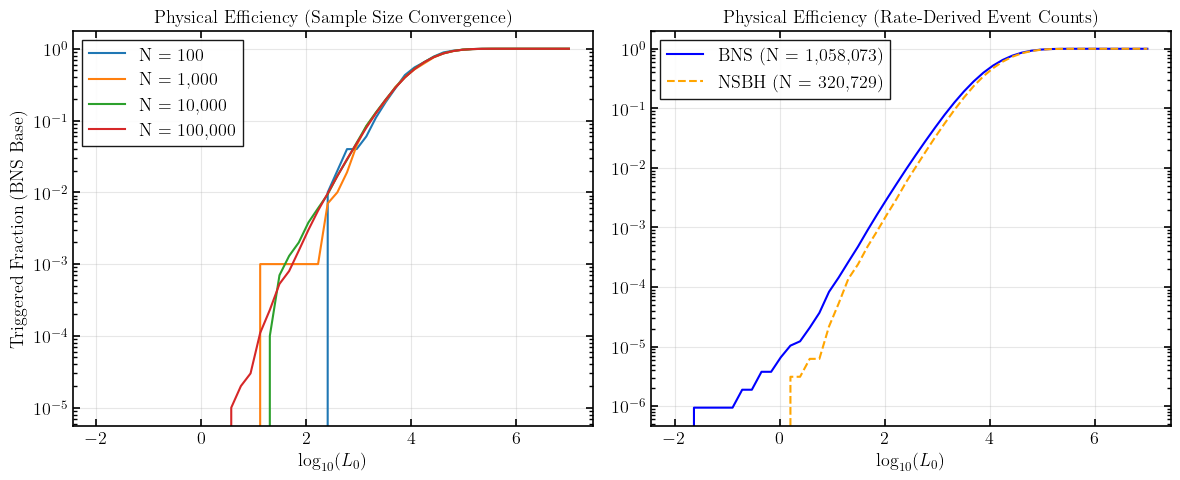

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid as cumtrapz
from scipy.interpolate import interp1d

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import create_k_interpolator, compute_luminosity_distance

def build_redshift_ppf(z_interp_func, z_min=1e-3, z_max=15.0, n_points=1000):
    z_fine = np.linspace(z_min, z_max, n_points)
    dP_dz = z_interp_func(z_fine)
    cdf_fine = cumtrapz(dP_dz, z_fine, initial=0)
    cdf_fine /= cdf_fine[-1]
    return interp1d(
        cdf_fine, 
        z_fine, 
        kind='linear', 
        bounds_error=False, 
        fill_value=(z_min, z_max)
    )

def lognormal_numpy_local(mu, sigma, n, rng):
    l10 = np.log(10)
    return rng.lognormal(mean=mu*l10, sigma=sigma*l10, size=n)

def luminosity_gen_local(A, n, rng):
    shape = (A - 1) / A
    return rng.gamma(shape, size=n) ** (-1 / A)

def generate_realistic_base_flux(
    data_obj, redshift_ppf, k_interpolator, L_mu_E, sigma_E, A_index, n_events
):
    rng = np.random.default_rng(123)
    z_samples = redshift_ppf(rng.uniform(size=n_events))
    d_L = compute_luminosity_distance(z_samples)
    
    E_p_rest = lognormal_numpy_local(L_mu_E, sigma_E, n_events, rng=rng)
    E_p_obs = E_p_rest / (1 + z_samples)
    
    lum_scatter = luminosity_gen_local(A_index, n_events, rng=rng)
    
    pts = np.column_stack((np.log10(E_p_obs), z_samples))
    k_corr = k_interpolator(pts)
    
    return lum_scatter / (4 * np.pi * d_L**2 * k_corr) * 6.242e8

def compute_efficiency_curve(base_flux, L0_grid, pflux_min=4.0):
    efficiencies = np.zeros_like(L0_grid)
    for i, L0 in enumerate(L0_grid):
        scaled_flux = base_flux * 10 ** (L0 + 49)
        efficiencies[i] = np.mean(scaled_flux > pflux_min)
    return efficiencies

def test_realistic_efficiency(alphas, fixed_params, datafiles):
    """Executes both fluctuation and realistic rate tests using your datafiles."""
    
    # Extract the first alpha for validation
    alpha = alphas[0]
    fixed = fixed_params[alpha]
    L_mu_E = fixed["L_mu_E"]
    sigma_E = fixed["sigma_E"]
    A_index = fixed["A_index"]

    demo_params = {"z_model": f"fiducial_delayed_{alpha}"}
    
    bns_params, nsbh_data, _ = initialize_combined_simulation(
        datafiles=datafiles,
        params=demo_params,
        nsbh_population="fiducial_delayed_cut",
        nsbh_alpha=alpha,
    )

    k_interpolator = create_k_interpolator()
    L0_grid = np.linspace(-2, 7, 50)
    
    bns_ppf = build_redshift_ppf(bns_params.P_z_interp)
    nsbh_ppf = build_redshift_ppf(nsbh_data.P_z_interp)

    # Test 1: Fluctuations across different N values
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    event_counts = [100, 1_000, 10_000, 100_000]
    for n in event_counts:
        base_flux = generate_realistic_base_flux(
            bns_params, bns_ppf, k_interpolator, L_mu_E, sigma_E, A_index, n
        )
        eff_curve = compute_efficiency_curve(base_flux, L0_grid)
        plt.plot(L0_grid, eff_curve, label=f"N = {n:,}")

    plt.title("Physical Efficiency (Sample Size Convergence)")
    plt.xlabel(r"$\log_{10}(L_0)$")
    plt.ylabel("Triggered Fraction (BNS Base)")
    plt.legend()
    plt.yscale("log")
    plt.grid(True)

    # Test 2: Rate-derived realistic inputs
    plt.subplot(1, 2, 2)
    bns_events  = int(bns_params.triggered_years * bns_params.total_merger_rate)
    nsbh_events = int(bns_params.triggered_years * nsbh_data.total_merger_rate)

    bns_base_flux   = generate_realistic_base_flux(
        bns_params, bns_ppf, k_interpolator, L_mu_E, sigma_E, A_index, bns_events
    )
    nsbh_base_flux  = generate_realistic_base_flux(
        nsbh_data, nsbh_ppf, k_interpolator, L_mu_E, sigma_E, A_index, nsbh_events
    )

    bns_eff_curve   = compute_efficiency_curve(bns_base_flux, L0_grid)
    nsbh_eff_curve  = compute_efficiency_curve(nsbh_base_flux, L0_grid)

    plt.plot(
        L0_grid, 
        bns_eff_curve, 
        label=f"BNS (N = {bns_events:,})", 
        color="blue"
    )
    plt.plot(
        L0_grid, 
        nsbh_eff_curve, 
        label=f"NSBH (N = {nsbh_events:,})", 
        color="orange", 
        linestyle="dashed"
    )

    plt.title("Physical Efficiency (Rate-Derived Event Counts)")
    plt.xlabel(r"$\log_{10}(L_0)$")
    plt.legend()
    plt.grid(True)
    plt.yscale("log")
    plt.tight_layout()
    plt.show()

test_realistic_efficiency(
    alphas=possible_alpha,
    fixed_params=fixed_params,
    datafiles=datafiles)

Loading existing directory  : Output_files/grid_likelihood_alpha_A0.5
Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Rendering predictive checks mapped for alpha: A0.5


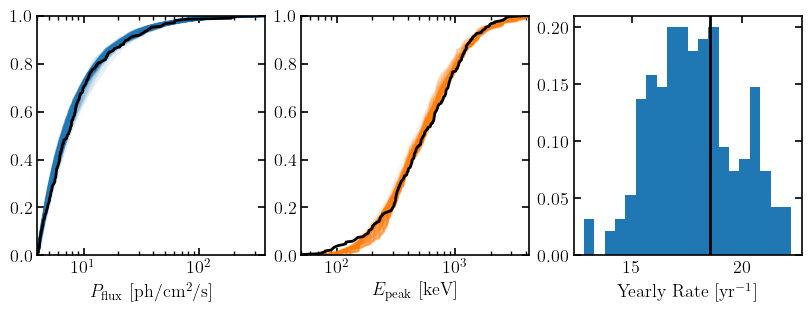

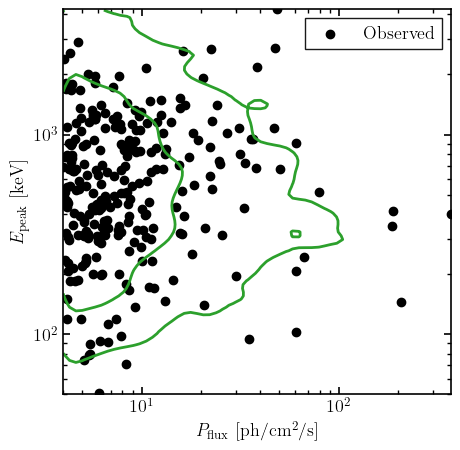

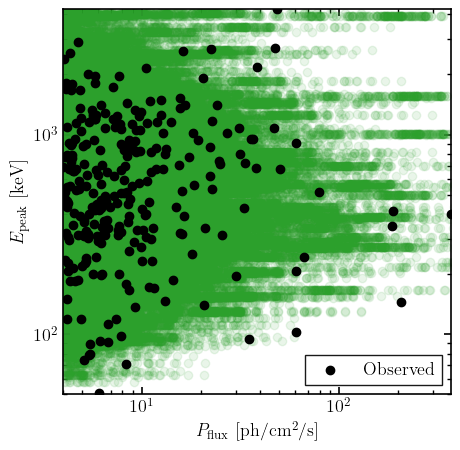

Loading existing directory  : Output_files/grid_likelihood_alpha_A1.0
Using redshift model: samples_fiducial_delayed_A1.0_BNSs_0.dat with 342071 BNSs.
Computed total merger rate: 343741.1 yr^-1 (local R_0 = 107.4 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 11117.2 yr^-1 (local R_0 = 2.3 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A1.0
  BHNSs local rate R_0 = 2.3 Gpc^-3 yr^-1
  BHNSs total rate     = 11117 yr^-1
  1-year z sample size = 11117
Rendering predictive checks mapped for alpha: A1.0


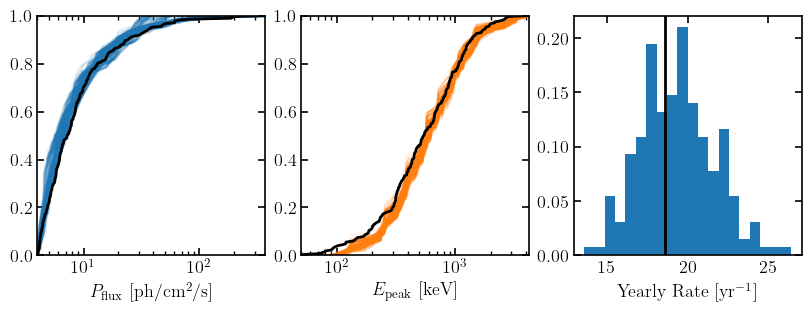

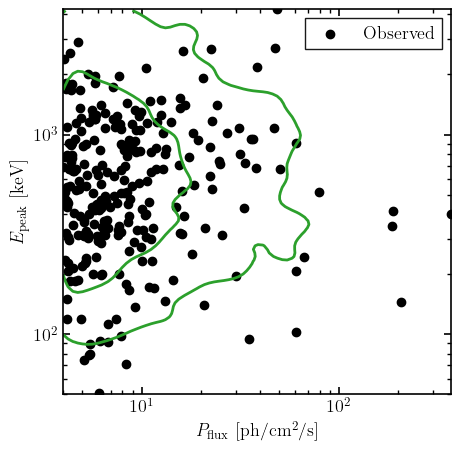

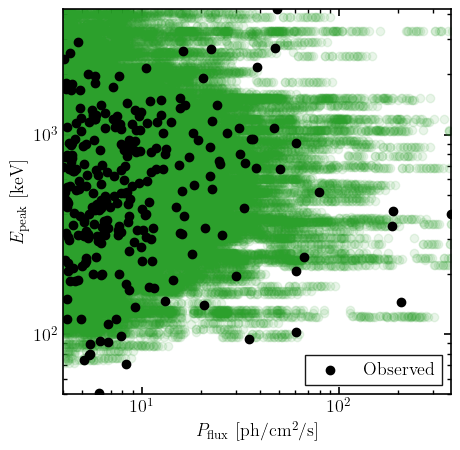

Loading existing directory  : Output_files/grid_likelihood_alpha_A3.0
Using redshift model: samples_fiducial_delayed_A3.0_BNSs_0.dat with 358417 BNSs.
Computed total merger rate: 360097.8 yr^-1 (local R_0 = 178.9 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4936.9 yr^-1 (local R_0 = 1.2 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A3.0
  BHNSs local rate R_0 = 1.2 Gpc^-3 yr^-1
  BHNSs total rate     = 4937 yr^-1
  1-year z sample size = 4936
Rendering predictive checks mapped for alpha: A3.0


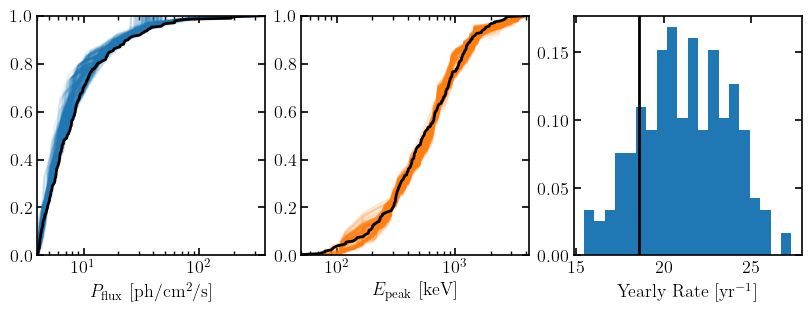

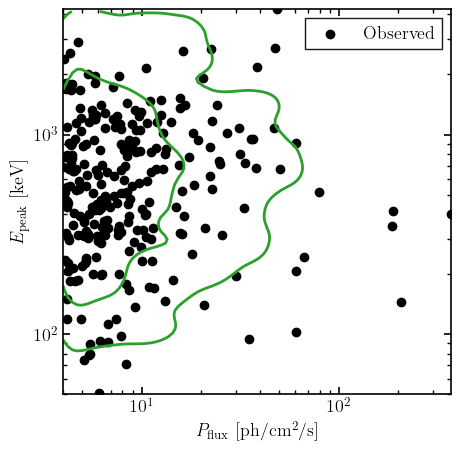

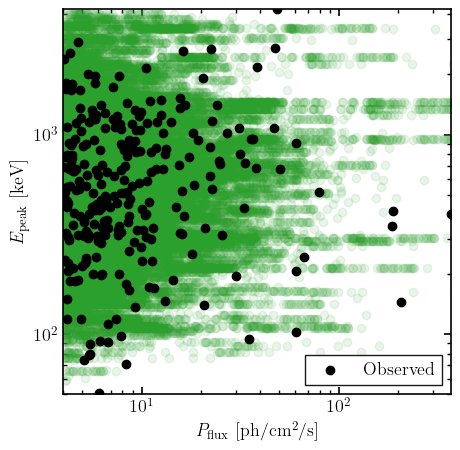

Loading existing directory  : Output_files/grid_likelihood_alpha_A5.0
Using redshift model: samples_fiducial_delayed_A5.0_BNSs_0.dat with 136203 BNSs.
Computed total merger rate: 136874.3 yr^-1 (local R_0 = 127.8 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 4095.2 yr^-1 (local R_0 = 1.0 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A5.0
  BHNSs local rate R_0 = 1.0 Gpc^-3 yr^-1
  BHNSs total rate     = 4095 yr^-1
  1-year z sample size = 4095
Rendering predictive checks mapped for alpha: A5.0


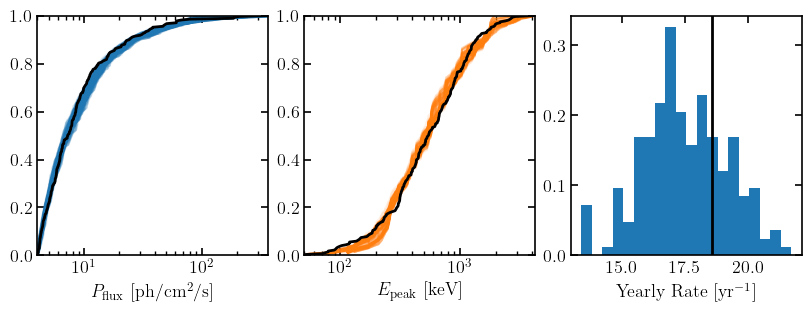

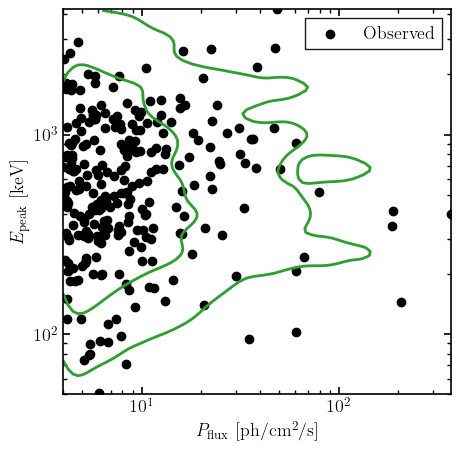

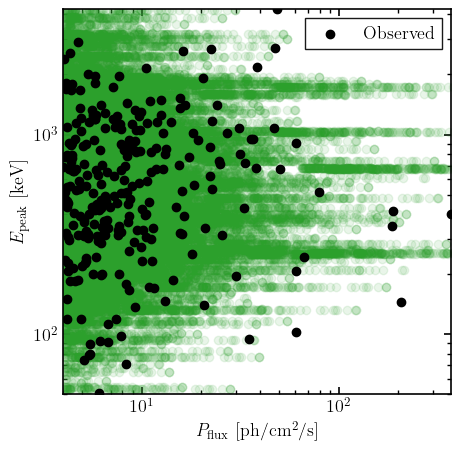

In [ ]:
from mcmc_runner import draw_grid_samples, setup_forward_ppc, plot_ppc
import src.init

for alpha in possible_alpha:
    grid_path = (
        src.init.create_run_dir(
            f"grid_likelihood_alpha_{alpha}",
            output_files_default="Output_files",
        )
        / "grid_eval.npz"
    )

    if not grid_path.exists():
        continue
        
    full_draws = draw_grid_samples(grid_path, n_samples=20_000)
    
    # 200 evaluations accurately map the space without massive latency.
    ppc_draws = full_draws[np.random.choice(len(full_draws), 200, replace=False)]

    forward_model_func, observed_data = setup_forward_ppc(
        alpha=alpha,
        geom_eff_func=geom_eff_func,
        datafiles=datafiles,
        fixed_params=fixed_params,
    )

    print(f"Rendering predictive checks mapped for alpha: {alpha}")
    plot_ppc(
        theta_draws=ppc_draws,
        forward_model_ppc=forward_model_func,
        observed=observed_data,
    )


Plotting autocorrelation for alpha=A0.5


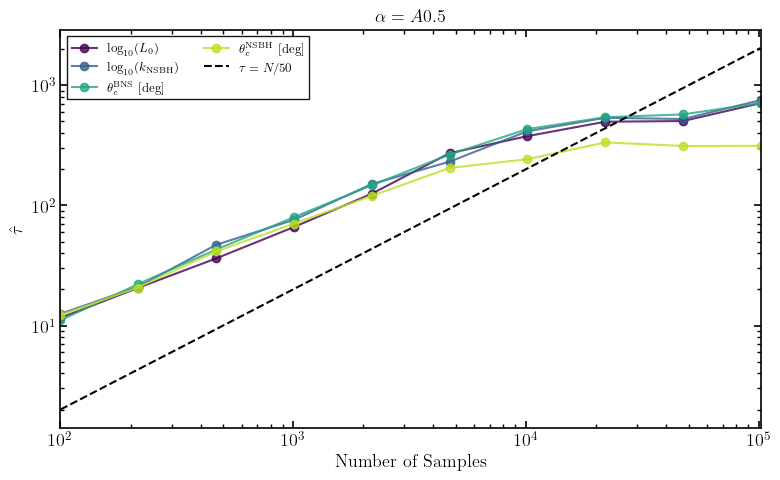

In [ ]:
import emcee
from mcmc_runner import labels as param_labels

def plot_alpha_autocorrelation(alpha, backend_path, labels, c=5.0, filename=None, close=True):
    chain = emcee.backends.HDFBackend(backend_path).get_chain()
    n_steps, _, n_params = chain.shape
    n_vals = np.unique(np.clip(np.exp(np.linspace(np.log(100), np.log(n_steps), 10)).astype(int), 100, n_steps))

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_params))

    for i in range(n_params):
        tau = [np.mean(emcee.autocorr.integrated_time(chain[:n, :, i], c=c, tol=0, quiet=True)) for n in n_vals]
        ax.loglog(n_vals, tau, 'o-', color=colors[i], label=labels[i], alpha=0.8)

    ax.plot(n_vals, n_vals / 50, '--k', lw=1.5, label=r'$\tau = N/50$')
    ax.set(xlabel='Number of Samples', ylabel=r'$\hat{\tau}$', xlim=(100, n_steps))
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.legend(fontsize=9, ncol=2)

    fig.tight_layout()
    if filename is None:
        filename = f'autocorrelation_{alpha}.pdf'
    fig.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    if close:
        plt.close(fig)
    return fig

for alpha in possible_alpha:
    print(f'Plotting autocorrelation for alpha={alpha}')
    # not for baseline but for the new runs, which are more relevant for convergence diagnostics
    path = Path(f"Output_files/midpoint_complete_alpha_{alpha}/emcee.h5")
    plot_alpha_autocorrelation(alpha, path, param_labels)
    break

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
Loading existing directory  : Output_files/midpoint_complete_alpha_A0.5


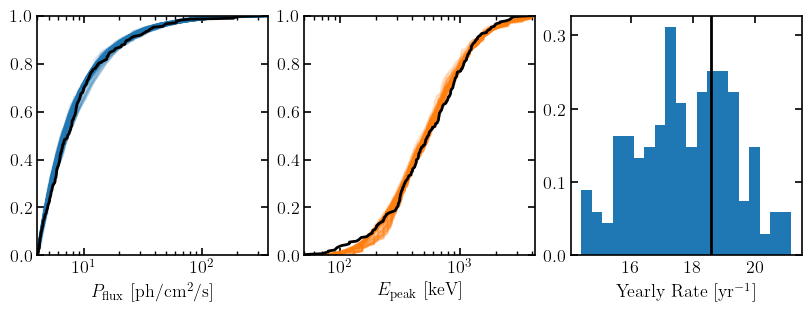

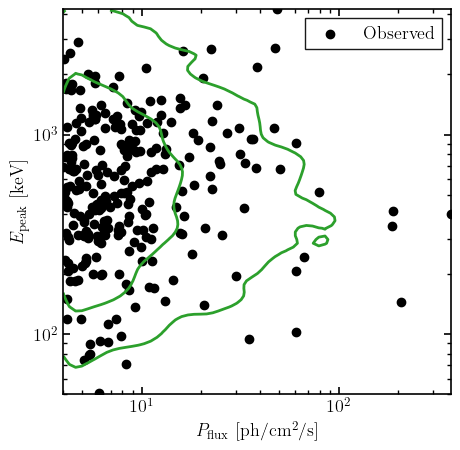

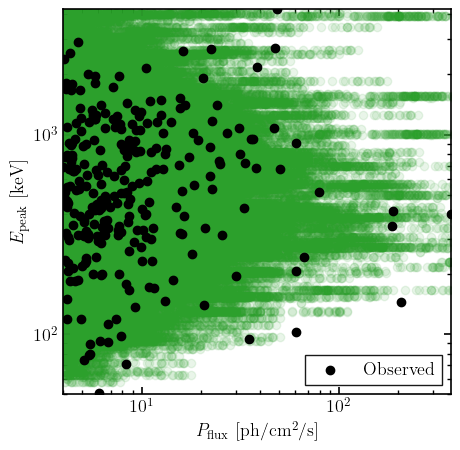

(<Figure size 500x500 with 1 Axes>,
 <Axes: xlabel='$P_{\\mathrm{flux}}$ [ph/cm$^2$/s]', ylabel='$E_{\\mathrm{peak}}$ [keV]'>)

In [ ]:
from mcmc_runner import _load_chain, setup_forward_ppc, plot_ppc

alpha_cdf = possible_alpha[0]
forward_model_ppc, observed = setup_forward_ppc(
    alpha=alpha_cdf,
    geom_eff_func=geom_eff_func,
    fixed_params=fixed_params,
)

_, flat, _ = _load_chain(alpha_cdf, burn_frac=0.3, thin=20)

idx = np.random.default_rng(1234).choice(
    len(flat),
    size=200,
    replace=False,
)

theta_draws = flat[idx]
plot_ppc(
    theta_draws,
    forward_model_ppc,
    observed,
)